# Compare raw and preprocessed training data

This notebook compares the raw training split with the saved outputs of Pipeline A (tree models) and Pipeline B (linear/distance models). It is descriptive only: the test split is not loaded or used.


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').is_dir():
    raise FileNotFoundError('Run this notebook from the project root or experiments directory.')

sys.path.insert(0, str(PROJECT_ROOT))
FIGURE_DIR = PROJECT_ROOT / 'experiments' / 'figures' / 'compare_data'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
from src.core.data_preprocessing import RISK_CLASS_TO_INT


In [3]:
train_raw = pd.read_csv(PROJECT_ROOT / 'data' / 'splits' / 'train.csv')

In [4]:
train_tree = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'tree' / 'train.csv')
train_linear = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'linear' / 'train.csv')

expected_rows = len(train_raw)
raw_target = train_raw['risk_class'].map(RISK_CLASS_TO_INT).reset_index(drop=True)
for name, data in {'Tree': train_tree, 'Linear': train_linear}.items():
    if len(data) != expected_rows:
        raise ValueError(f'{name} artifact has {len(data)} rows; expected {expected_rows}.')
    expected_target = data['risk_class'].map(RISK_CLASS_TO_INT)
    if not expected_target.equals(data['risk_class_encoded']):
        raise ValueError(f'{name} artifact violates the required risk-class mapping.')
    if not expected_target.reset_index(drop=True).equals(raw_target):
        raise ValueError(f'{name} artifact is not aligned with the raw training rows.')

In [5]:
# Config
NUMERIC_COLS = [
    'elevation_m', 'drainage_density_km_per_km2',
    'storm_drain_proximity_m',
    'historical_rainfall_intensity_mm_hr',
    'return_period_years'
]
NEW_FEATURES = ['G4_is_very_low_elev', 'G2_rain_x_return']
COLORS = {
    'Raw'   : '#5B9BD5',
    'Tree'  : '#70AD47',
    'Linear': '#ED7D31'
}
CLASS_ORDER = ['Low', 'Medium', 'High']
CLASS_COLORS = {'Low': '#6BCB77', 'Medium': '#FFD93D', 'High': '#FF6B6B'}
datasets = {
    'Raw': train_raw,
    'Tree': train_tree,
    'Linear': train_linear,
}

def add_encoded_target(data):
    result = data.copy()
    if 'risk_class_encoded' not in result.columns:
        result['risk_class_encoded'] = result['risk_class'].map(RISK_CLASS_TO_INT)
    if result['risk_class_encoded'].isna().any():
        raise ValueError('Unknown or missing risk class found.')
    return result

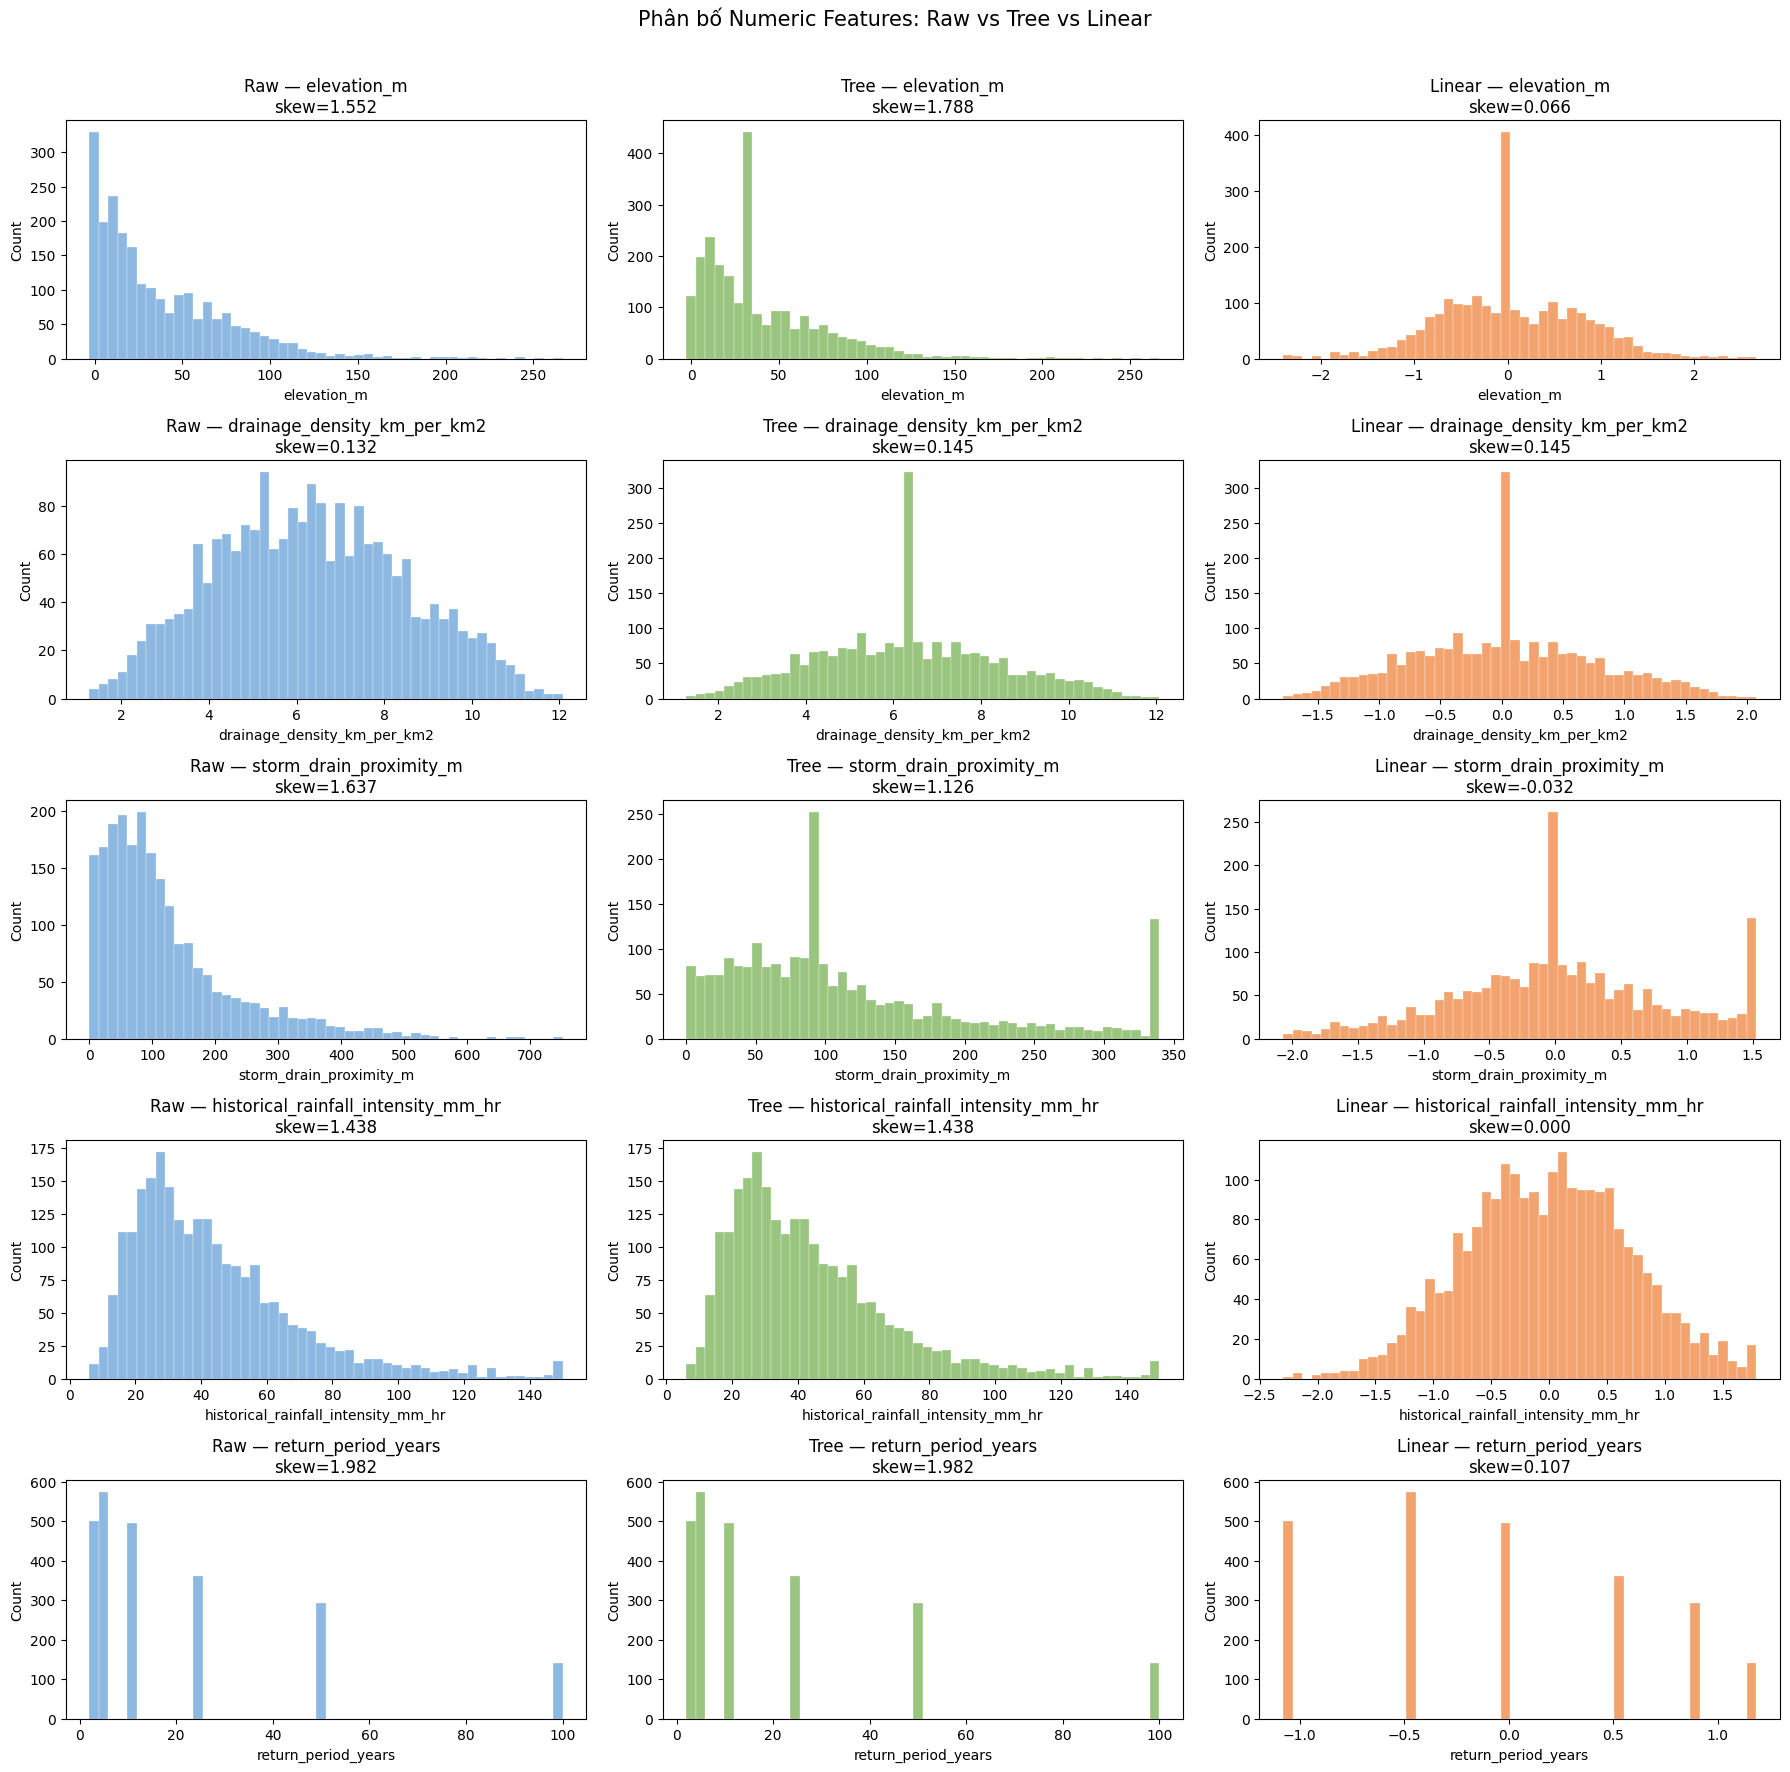

In [6]:
# ================================================================== #
# 2. HISTOGRAM — Phân bố numeric features
# ================================================================== #
fig, axes = plt.subplots(len(NUMERIC_COLS), 3, figsize=(18, len(NUMERIC_COLS) * 3.5))
fig.suptitle('Phân bố Numeric Features: Raw vs Tree vs Linear', fontsize=15, y=1.01)

for row, col in enumerate(NUMERIC_COLS):
    for ax_col, (name, data) in enumerate(datasets.items()):
        ax = axes[row, ax_col]

        if col not in data.columns:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_title(f'{name} — {col}')
            continue

        vals = data[col].dropna()
        ax.hist(vals, bins=50, color=COLORS[name],
                alpha=0.7, edgecolor='white', linewidth=0.3)
        skew = vals.skew()
        ax.set_title(f'{name} — {col}\nskew={skew:.3f}')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'histogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ================================================================== #
# 3. SKEWNESS TABLE
# ================================================================== #
skew_data = {}
for name, data in datasets.items():
    skew_data[name] = {
        col: round(data[col].skew(), 3) if col in data.columns else 'N/A'
        for col in NUMERIC_COLS
    }

skew_df = pd.DataFrame(skew_data)

def highlight_skew(val):
    if val == 'N/A':
        return 'background-color: #d3d3d3; color: gray'
    if abs(val) > 1:
        return 'background-color: #ff9999'   # Đỏ — nặng
    if abs(val) > 0.5:
        return 'background-color: #ffdd99'   # Vàng — vừa
    return 'background-color: #99dd99'       # Xanh — ổn

print("=== SKEWNESS TABLE ===")
display(skew_df.style.map(highlight_skew))

print("\n=== SUMMARY ===")
for name, data in datasets.items():
    cols  = [c for c in NUMERIC_COLS if c in data.columns]
    skews = [abs(data[c].skew()) for c in cols]
    print(f"{name:8s} | mean|skew|={np.mean(skews):.3f} "
          f"| max|skew|={np.max(skews):.3f}")

=== SKEWNESS TABLE ===


,Raw,Tree,Linear
elevation_m,1.552000,1.788000,0.066000
drainage_density_km_per_km2,0.132000,0.145000,0.145000
storm_drain_proximity_m,1.637000,1.126000,-0.032000
historical_rainfall_intensity_mm_hr,1.438000,1.438000,0.000000
return_period_years,1.982000,1.982000,0.107000



=== SUMMARY ===
Raw      | mean|skew|=1.348 | max|skew|=1.982
Tree     | mean|skew|=1.296 | max|skew|=1.982
Linear   | mean|skew|=0.070 | max|skew|=0.145


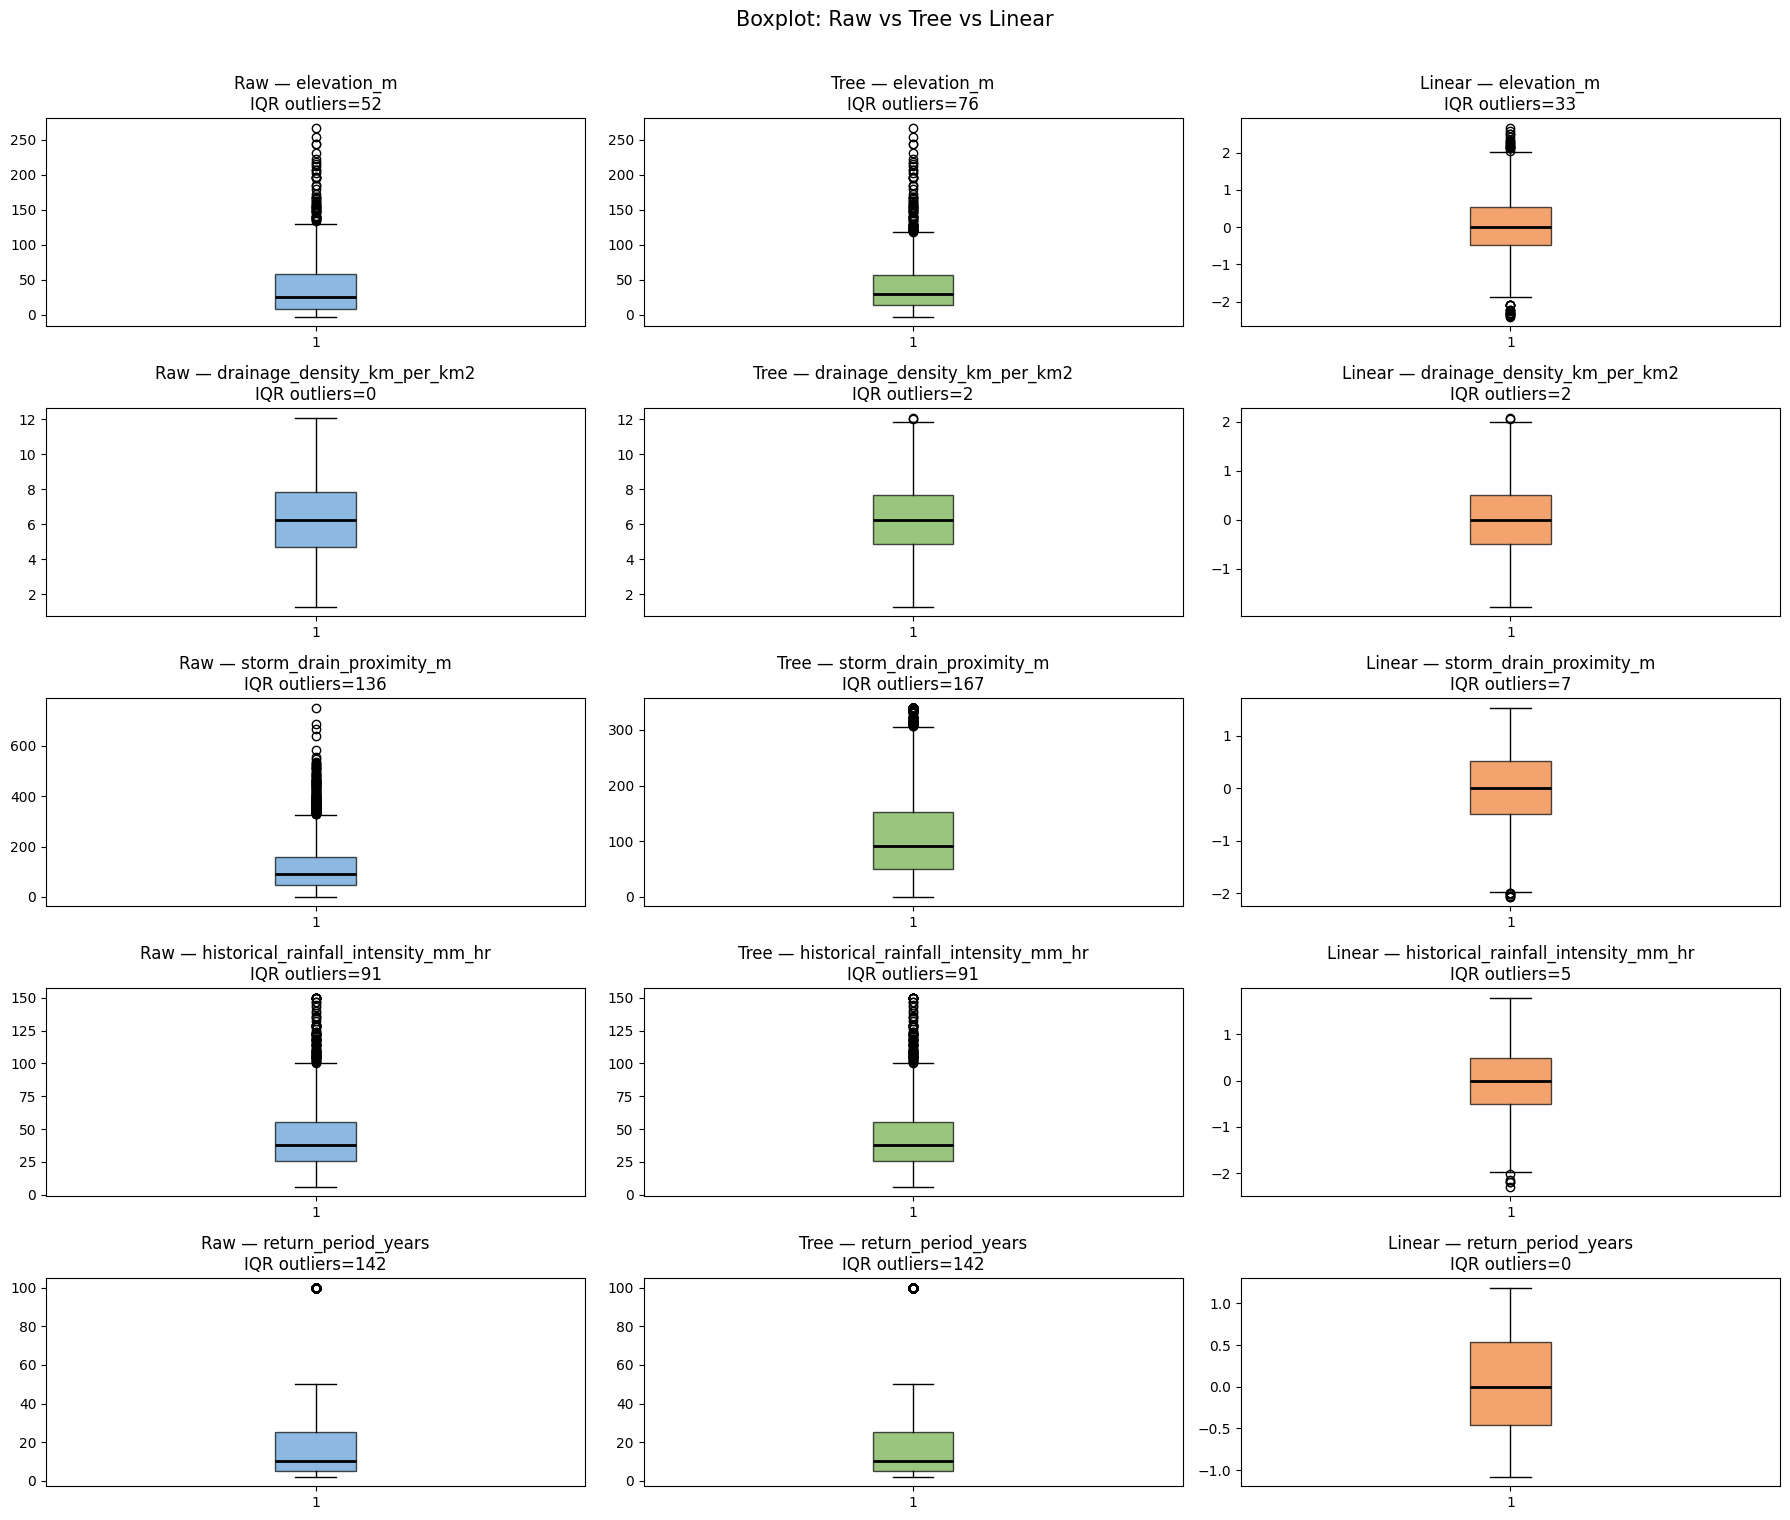

In [8]:
# ================================================================== #
# 4. BOXPLOT — Outlier trước/sau
# ================================================================== #
fig, axes = plt.subplots(len(NUMERIC_COLS), 3,
                         figsize=(18, len(NUMERIC_COLS) * 3))
fig.suptitle('Boxplot: Raw vs Tree vs Linear', fontsize=15, y=1.01)

for row, col in enumerate(NUMERIC_COLS):
    for ax_col, (name, data) in enumerate(datasets.items()):
        ax = axes[row, ax_col]

        if col not in data.columns:
            ax.set_visible(False)
            continue

        vals = data[col].dropna()
        bp   = ax.boxplot(vals, patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
        bp['boxes'][0].set_facecolor(COLORS[name])
        bp['boxes'][0].set_alpha(0.7)

        q1, q3 = vals.quantile([0.25, 0.75])
        iqr = q3 - q1
        n_outliers = ((vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)).sum()
        ax.set_title(f'{name} — {col}\nIQR outliers={n_outliers}')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'boxplot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

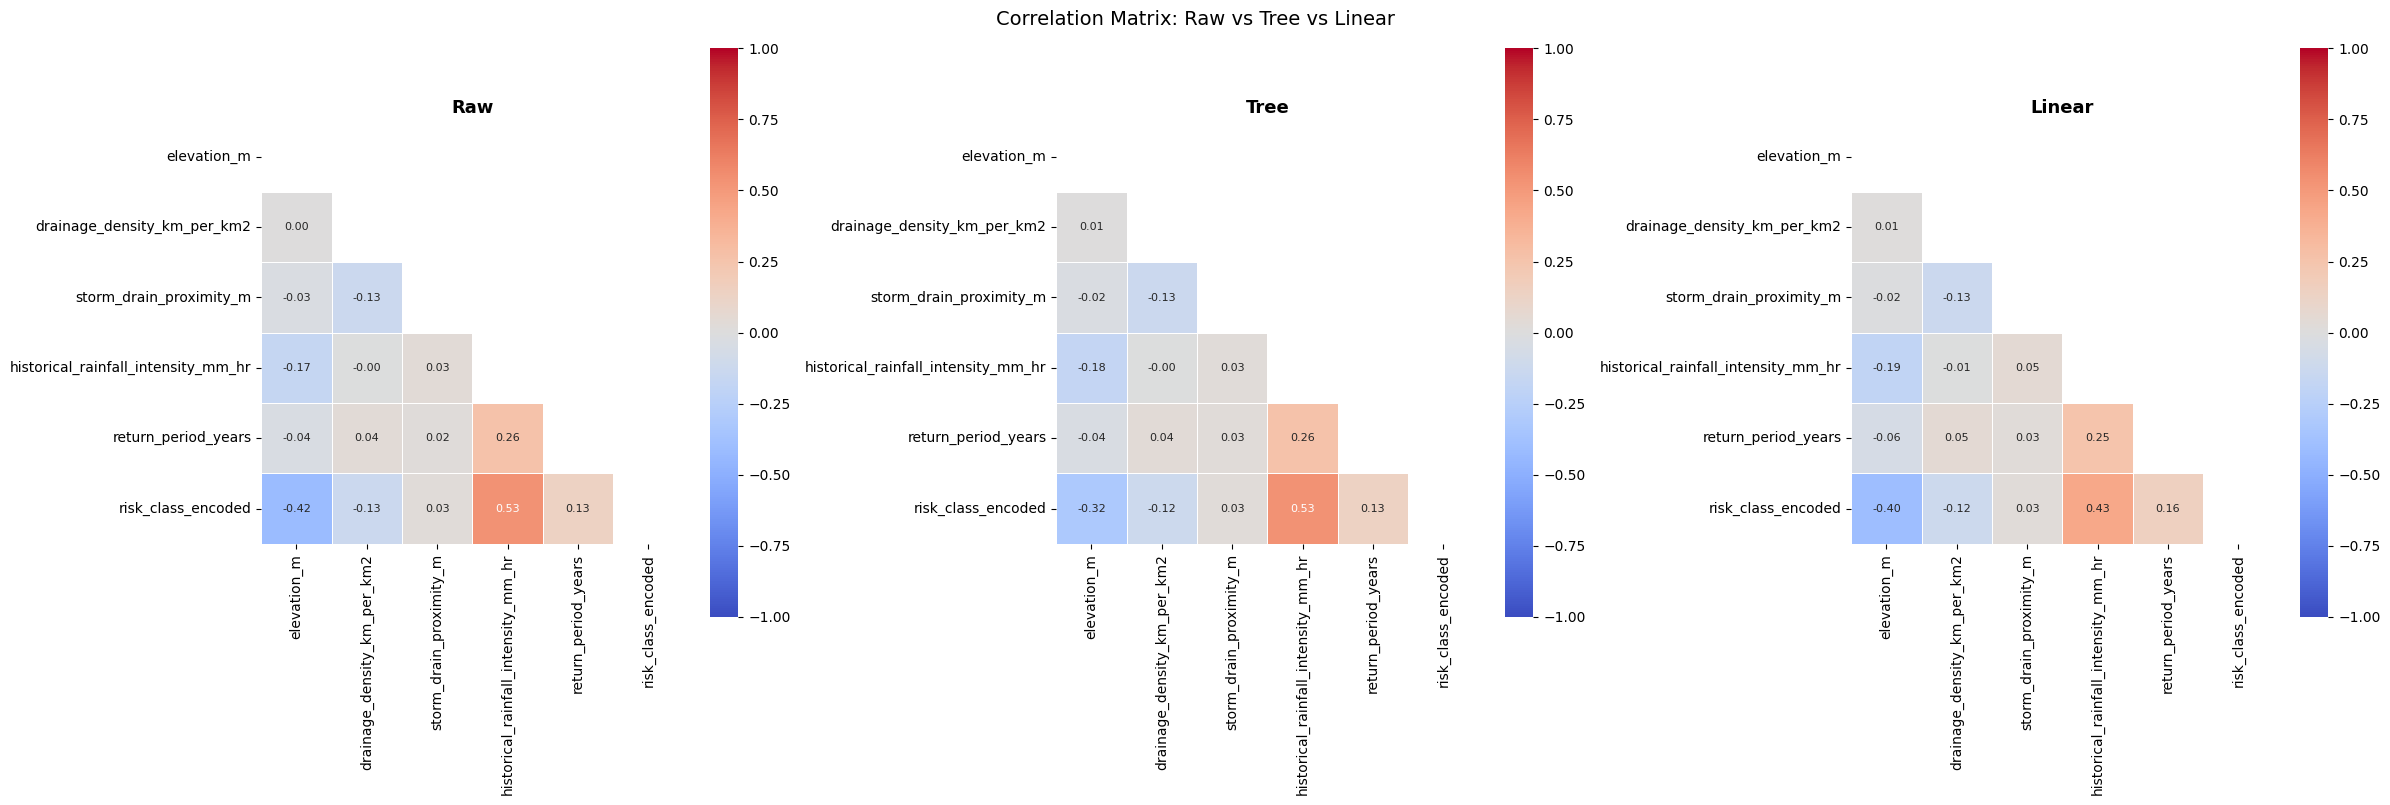


=== CORRELATION VỚI TARGET ===
Feature                                            Raw     Tree   Linear
---------------------------------------------------------------------------
elevation_m                                     -0.422   -0.320   -0.400
drainage_density_km_per_km2                     -0.127   -0.121   -0.121
storm_drain_proximity_m                          0.030    0.030    0.028
historical_rainfall_intensity_mm_hr              0.534    0.534    0.428
return_period_years                              0.135    0.135    0.156


In [9]:
# ================================================================== #
# 6. CORRELATION MATRIX
# ================================================================== #
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('Correlation Matrix: Raw vs Tree vs Linear', fontsize=14)

correlation_datasets = {name: add_encoded_target(data) for name, data in datasets.items()}

for ax, (name, data) in zip(axes, correlation_datasets.items()):
    target_col = 'risk_class_encoded'

    num_cols = [c for c in NUMERIC_COLS if c in data.columns] + [target_col]
    corr     = data[num_cols].corr()
    mask     = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, mask=mask,
                square=True, linewidths=0.5, annot_kws={'size': 8})
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'correlation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation với target — so sánh 3 bộ
print("\n=== CORRELATION VỚI TARGET ===")
print(f"{'Feature':<45} {'Raw':>8} {'Tree':>8} {'Linear':>8}")
print("-" * 75)

for col in NUMERIC_COLS:
    row = []
    for name, data in correlation_datasets.items():
        if col in data.columns:
            corr_val = data[col].corr(data['risk_class_encoded'])
            row.append(f"{corr_val:8.3f}")
        else:
            row.append(f"{'N/A':>8}")
    print(f"{col:<45} {' '.join(row)}")

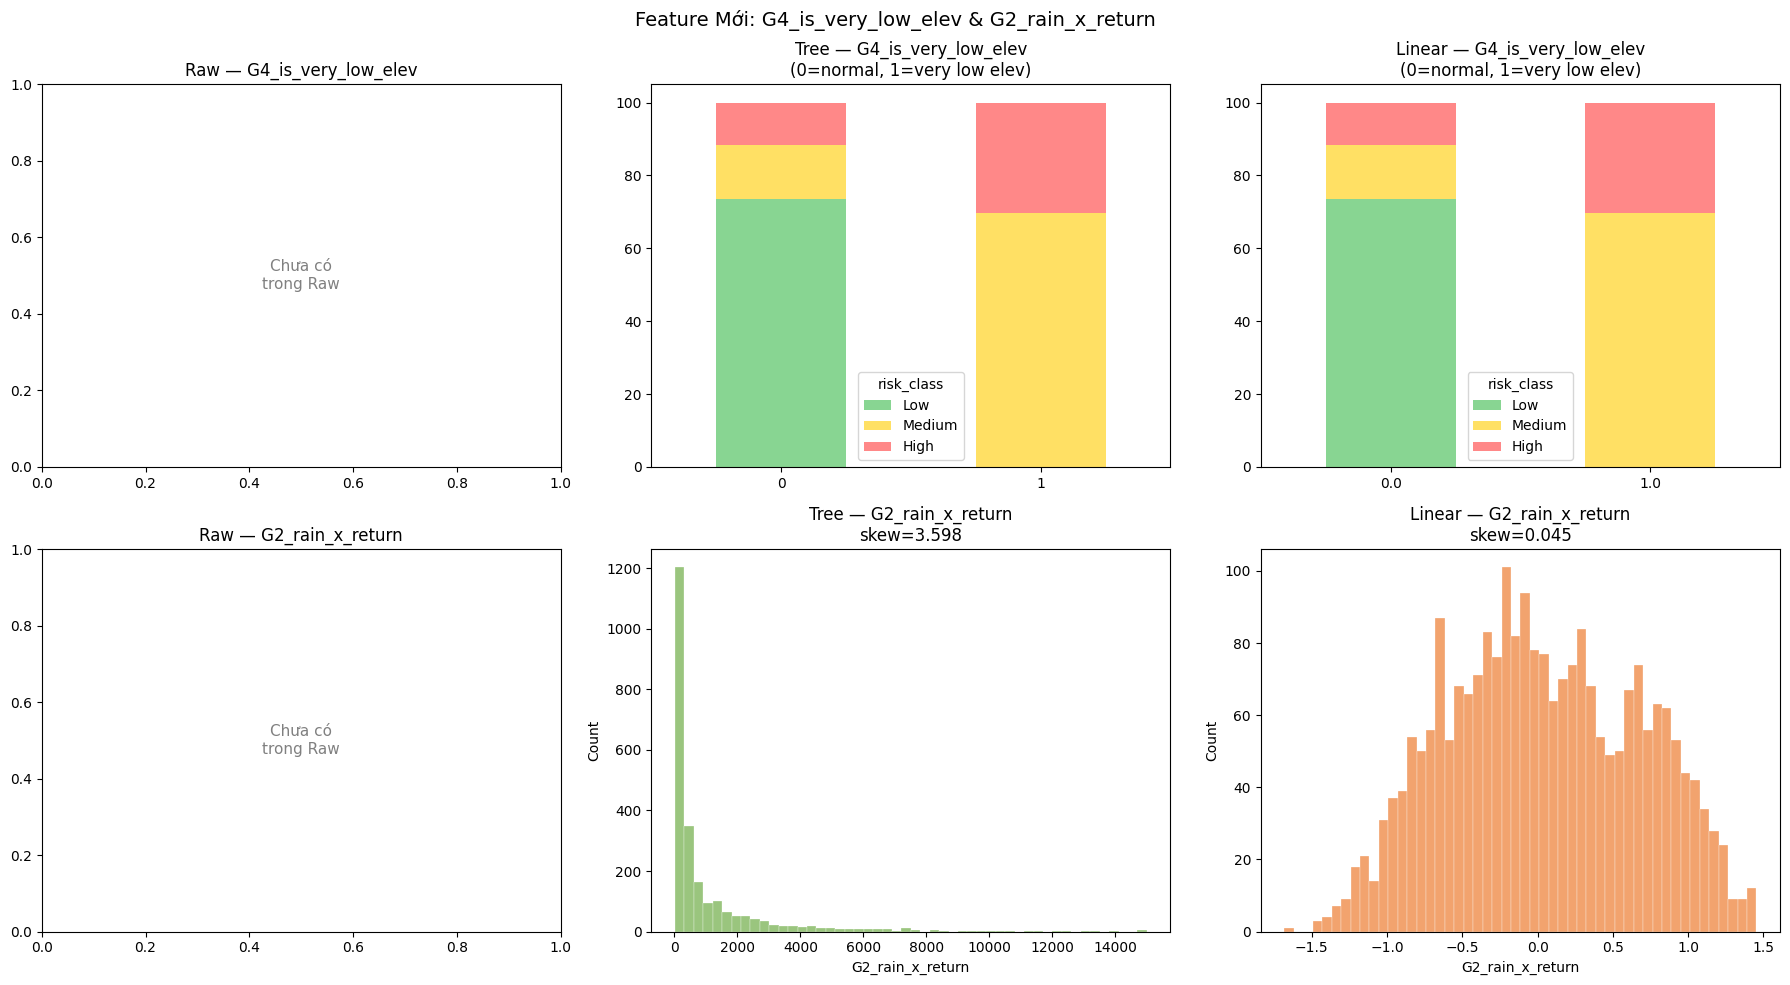


=== FEATURE MỚI vs TARGET ===

G4_is_very_low_elev:
  Tree    : corr=0.361
  Linear  : corr=0.361

G2_rain_x_return:
  Tree    : corr=0.346
  Linear  : corr=0.279


In [10]:
# ================================================================== #
# 7. FEATURE MỚI — G4_is_very_low_elev & G2_rain_x_return
# ================================================================== #
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Mới: G4_is_very_low_elev & G2_rain_x_return', fontsize=14)

for col_idx, feat in enumerate(NEW_FEATURES):
    for row_idx, (name, data) in enumerate(datasets.items()):
        ax = axes[col_idx, row_idx]

        if feat not in data.columns:
            ax.text(0.5, 0.5, f'Chưa có\ntrong {name}',
                    ha='center', va='center',
                    transform=ax.transAxes, fontsize=11, color='gray')
            ax.set_title(f'{name} — {feat}')
            continue

        vals = data[feat].dropna()

        if feat == 'G4_is_very_low_elev':
            # Binary feature → bar chart theo class
            if 'risk_class' in data.columns:
                ct = pd.crosstab(data[feat], data['risk_class'],
                                 normalize='index') * 100
                ct = ct.reindex(columns=CLASS_ORDER, fill_value=0)
                ct.plot(
                    kind='bar', ax=ax, stacked=True,
                    color=[CLASS_COLORS[c] for c in CLASS_ORDER], alpha=0.8
                )
                ax.set_title(f'{name} — {feat}\n(0=normal, 1=very low elev)')
                ax.set_xlabel('')
                ax.tick_params(axis='x', rotation=0)
            else:
                ax.bar([0, 1], vals.value_counts().sort_index(),
                       color=COLORS[name], alpha=0.7)
                ax.set_title(f'{name} — {feat}')

        else:  # G2_rain_x_return
            ax.hist(vals, bins=50, color=COLORS[name],
                    alpha=0.7, edgecolor='white', linewidth=0.3)
            skew = vals.skew()
            ax.set_title(f'{name} — {feat}\nskew={skew:.3f}')
            ax.set_xlabel(feat)
            ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'new_features_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation của feature mới với target
print("\n=== FEATURE MỚI vs TARGET ===")
for feat in NEW_FEATURES:
    print(f"\n{feat}:")
    for name, data in correlation_datasets.items():
        if feat in data.columns:
            corr = data[feat].corr(data['risk_class_encoded'])
            print(f"  {name:8s}: corr={corr:.3f}")

In [11]:
# ================================================================== #
# 8. TỔNG KẾT
# ================================================================== #
print("=" * 60)
print("TỔNG KẾT SO SÁNH")
print("=" * 60)

print(f"""
Shape:
  Raw    : {train_raw.shape}
  Tree   : {train_tree.shape}
  Linear : {train_linear.shape}

Skewness (mean |skew| numeric features):""")

for name, data in datasets.items():
    cols  = [c for c in NUMERIC_COLS if c in data.columns]
    skews = [abs(data[c].skew()) for c in cols]
    print(f"  {name:8s}: {np.mean(skews):.3f}")

print(f"""
Missing values sau preprocessing:
  Tree   : {train_tree.isnull().sum().sum()} NaN
  Linear : {train_linear.isnull().sum().sum()} NaN

Features mới (corr với target):""")

for feat in NEW_FEATURES:
    if feat in train_tree.columns and 'risk_class_encoded' in train_tree.columns:
        corr = train_tree[feat].corr(train_tree['risk_class_encoded'])
        print(f"  {feat}: {corr:.3f}")

TỔNG KẾT SO SÁNH

Shape:
  Raw    : (2370, 18)
  Tree   : (2370, 18)
  Linear : (2370, 38)

Skewness (mean |skew| numeric features):
  Raw     : 1.348
  Tree    : 1.296
  Linear  : 0.070

Missing values sau preprocessing:
  Tree   : 0 NaN
  Linear : 0 NaN

Features mới (corr với target):
  G4_is_very_low_elev: 0.361
  G2_rain_x_return: 0.346
